## Figure 5

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/fig5_overlap/`: 5 overlap levels x 5 seeds (panels e-h)
- `out/fig5_overlap_examples/`: one network per overlap level with recorded activity (panels b-d)
- `out/fig4_nohl/`: Figure 4 no-hidden-layer baseline, dashed reference line in panel g (optional)

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"

from pathlib import Path

import numpy as np

# PLOTTING
import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
from cmcrameri import cm as cmc

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})

from bcp.analysis import HydraRunOutput, HydraMultirun


def relu(x):
    return np.maximum(0, x)

#### Directory setup

In [2]:
# Panels are saved to <repo>/figures/fig5/<panel>_<description>.pdf
repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())

overlap_dir = repo_root / "out" / "fig5_overlap"
examples_dir = repo_root / "out" / "fig5_overlap_examples"
nohl_dir = repo_root / "out" / "fig4_nohl"

fig5_dir = repo_root / "figures" / "fig5"
fig5_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [3]:
cm = 1 / 2.54  # centimeters in inches

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh = '#0077B8'
color_openloop = 'gray'
color_closedloop = '#F49F1E'
color_target = 'black'

linewidth = 1.0

cmap = cmc.cmaps['navia']
cmap_max_val = 0.8
color_accent = cmap(0.5)

### Load runs

In [4]:
EXAMPLE_OVERLAP = 30 
X_AXIS_TRAINING = 'time'

In [5]:
def overlap_pct(run):
    return int(round(run.config['model']['overlap'] * 100))


results = {}
for folder in sorted(f for f in overlap_dir.iterdir() if f.is_dir()):
    mr = HydraMultirun(folder, result_files=['results.pkl'])
    table = mr.table(keys=['OL_R2', 'OL_loss', 'OL_error'])

    R2 = np.stack(table['OL_R2'])
    loss = np.stack(table['OL_loss'])
    OL_error = np.stack(table['OL_error'])  # [seeds, recordings, neurons]

    results[overlap_pct(mr[0])] = {
        'R2': R2,
        'final_R2': R2[:, -1],
        'loss': loss,
        'final_loss': loss[:, -1],
        # balance disruption: mean over neurons of |sum_t Delta_i(t)| before training
        'init_abs_error': np.abs(OL_error[:, 0, :]).mean(1),
    }

overlaps = sorted(results)
labels = [f'{o}' for o in overlaps]

x_run = mr[0]
if X_AXIS_TRAINING == 'time':
    X_LABEL_TRAINING = 'Time [mins]'
    X_TRAINING = x_run['training_time']
else:
    X_LABEL_TRAINING = 'Iteration'
    X_TRAINING = x_run['rec_iters']

examples = {}
for run_dir in sorted(examples_dir.glob('overlap*/seed*')):
    run = HydraRunOutput(run_dir)
    r = run.load_pickle('results.pkl')
    examples[overlap_pct(run)] = {
        'I_FF_bar': r['I_FF_bar'][0],   # first recording (before training), [time, neurons]
        'OL_I_IE': r['OL_I_IE'][0],
        'uOut_final': r['OL_uOut'][-1], # last recording, [time, 2]
    }
    del r

# No-hidden-layer baseline for panel g
nohl = HydraMultirun(nohl_dir, result_files=['results.pkl'])
R2_NO_HIDDEN = np.mean([run['OL_R2'][-1] for run in nohl])

In [6]:
for o in overlaps:
    d = results[o]
    print(f"{o:>2}% overlap | n={len(d['final_R2'])}"
          f" | final R2 {np.round(d['final_R2'], 3)}"
          f" | final loss {np.round(d['final_loss'], 4)}"
          f" | disruption {d['init_abs_error'].mean():.2f} +- {d['init_abs_error'].std():.2f}")
print('Example networks:', sorted(examples))
print('No hidden layer R2:', R2_NO_HIDDEN)

 0% overlap | n=5 | final R2 [0.996 0.998 0.998 0.997 0.998] | final loss [0.0021 0.0014 0.0015 0.0017 0.0015] | disruption 0.13 +- 0.02
10% overlap | n=5 | final R2 [0.994 0.988 0.992 0.991 0.992] | final loss [0.0039 0.0072 0.005  0.0056 0.005 ] | disruption 10.58 +- 1.19
20% overlap | n=5 | final R2 [0.986 0.986 0.988 0.987 0.989] | final loss [0.0086 0.0089 0.0074 0.0082 0.0067] | disruption 24.42 +- 1.87
30% overlap | n=5 | final R2 [0.938 0.914 0.963 0.981 0.984] | final loss [0.0366 0.0546 0.0219 0.0116 0.01  ] | disruption 39.62 +- 2.62
40% overlap | n=5 | final R2 [0.777 0.806 0.86  0.957 0.88 ] | final loss [0.1287 0.1097 0.0838 0.0259 0.0724] | disruption 60.93 +- 2.54
Example networks: [0, 10, 20, 30, 40]
No hidden layer R2: 0.5306146204471588


### Panel b: currents of an example neuron

In [7]:
figsize_balance_traj = (2.1*cm, 2.5*cm)
ex_neuron_idx = 22
alpha = 0.5
ylim_error = (-0.2, 0.2)

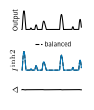

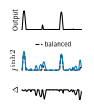

In [8]:
def plot_example_currents(ex, rectify_output):
    fig = MultiPanel(grid=[1]*3, figsize=figsize_balance_traj)
    for ax in fig.panels:
        for side in ['top', 'right', 'left', 'bottom']:
            ax.spines[side].set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

    I_E = relu(ex['I_FF_bar'][:, ex_neuron_idx])
    I_I = ex['OL_I_IE'][:, ex_neuron_idx]
    FR = relu(I_E - I_I) if rectify_output else I_E - I_I

    fig.panels[0].plot(FR, color='black', label='Output', lw=0.75)
    fig.panels[0].set_ylabel('Output', fontsize=5, labelpad=0)

    fig.panels[1].plot(alpha * I_E, color='black', linestyle='dashed', label='balanced', lw=0.75)
    fig.panels[1].plot(I_I, color=color_inh, lw=0.75)
    fig.panels[1].legend(loc=(0.2, 1), fontsize=5, handlelength=1, handletextpad=0.4)
    fig.panels[1].set_ylabel(r'$I^{\mathrm{inh2}}$', labelpad=0, fontsize=5)

    ERROR = alpha * I_E - I_I
    fig.panels[2].plot(ERROR, color='black', lw=0.75)
    fig.panels[2].set_ylim(*ylim_error)
    fig.panels[2].set_ylabel(r'$\Delta$', fontsize=5, labelpad=0)
    return fig


fig_b0 = plot_example_currents(examples[0], rectify_output=False)
plt.savefig(fig5_dir / 'b_currents_no_overlap.pdf')
plt.show()

fig_b1 = plot_example_currents(examples[EXAMPLE_OVERLAP], rectify_output=True)
fig_b1.panels[2].hlines(0, 0, len(examples[EXAMPLE_OVERLAP]['OL_I_IE']),
                        color='gray', lw=0.5, linestyle='dashed', zorder=-10)
plt.savefig(fig5_dir / 'b_currents_overlap.pdf')
plt.show()

/var/folders/hv/pkkqx_mx7s12wnhdkf46t2qr0000gn/T/ipykernel_57811/2850140295.py:16: UserWarning: The figure layout has changed to tight
  figLegend.tight_layout()


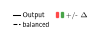

In [9]:
# Separate legend (not used in the paper)
handles0, labels0 = fig_b1.panels[0].get_legend_handles_labels()
handles1, labels1 = fig_b1.panels[1].get_legend_handles_labels()

custom_handle = (Patch(facecolor='red', edgecolor='red', linewidth=1, alpha=0.6),
                 Patch(facecolor='green', edgecolor='green', linewidth=1, alpha=0.6))
custom_label = r'+/- $\Delta$'

figLegend = plt.figure(figsize=(2.5*cm, 0.95*cm))
legend_ax = figLegend.add_subplot(111)
legend_ax.axis('off')
legend_ax.legend(handles0 + handles1 + [custom_handle], labels0 + labels1 + [custom_label],
                 loc='center', fontsize=5, ncol=2,
                 handler_map={tuple: HandlerTuple(ndivide=2)}, handlelength=1, handletextpad=0.4,
                 columnspacing=1)
figLegend.tight_layout()
figLegend.patch.set_alpha(0.0)
figLegend.savefig(fig5_dir / 'NA_b_legend.pdf', bbox_inches='tight')
plt.show()

### Panel c: E/I balance across the population

In [10]:
figsize_EvsI = (2.4*cm, 2.4*cm)
avg_from_step = 4000   # average over the last 1 s

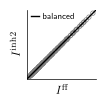

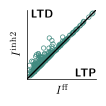

In [11]:
def balance_scatter(ex, color, legend_label):
    fig, ax = plt.subplots(1, 1, figsize=figsize_EvsI)
    I_E = alpha * relu(ex['I_FF_bar'][avg_from_step:, :]).mean(0)
    I_I = ex['OL_I_IE'][avg_from_step:, :].mean(0)
    ax.scatter(I_E, I_I, s=10, marker='o', facecolors='none', edgecolors=color)
    ax.plot([0, 1], [0, 1], color='black', lw=linewidth, label=legend_label)

    lim = 1.05 * np.max([I_E, I_I])
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box', anchor='SE')
    ax.set_xlabel(r'$I^{\mathrm{ff}}$', fontsize=8)
    ax.set_ylabel(r'$I^{\mathrm{inh2}}$', fontsize=8)
    return fig, ax


fig, ax = balance_scatter(examples[0], color_openloop, 'balanced')
ax.legend(loc='upper left', fontsize=6, handlelength=1, handletextpad=0.4,
          handleheight=0.5, borderpad=0.2, borderaxespad=0.2)
fig.savefig(fig5_dir / 'c_balance_scatter_no_overlap.pdf', bbox_inches='tight')
plt.show()

fig, ax = balance_scatter(examples[EXAMPLE_OVERLAP], color_accent, 'Balance')
ax.text(1, 0, r'\textbf{LTP}', fontsize=8, ha='right', va='bottom', transform=ax.transAxes)
ax.text(0.05, 1, r'\textbf{LTD}', fontsize=8, ha='left', va='top', transform=ax.transAxes)
fig.savefig(fig5_dir / 'c_balance_scatter_overlap.pdf', bbox_inches='tight')
plt.show()

### Panel d: output trajectories after training

In [12]:
figsize_traj_examples = (8.5*cm, 1.5*cm)
figsize_colorbar = (8.5*cm, 1*cm)
lim_traj = (-1.1, 1.1)

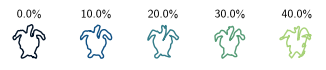

0 #031327
10 #105185
20 #327c89
30 #549b75
40 #a7d278


In [13]:
example_overlaps = sorted(examples)
max_example_overlap = max(example_overlaps)
colors_examples = [cmap(cmap_max_val * o / max_example_overlap) for o in example_overlaps]

fig = MultiPanel(grid=[len(example_overlaps)], figsize=figsize_traj_examples)
for ax, o, color in zip(fig.panels, example_overlaps, colors_examples):
    ax.axis('off')
    ax.set_aspect('equal', adjustable='box', anchor='SW')
    ax.set_xlim(*lim_traj)
    ax.set_ylim(*lim_traj)

    traj = examples[o]['uOut_final']
    ax.plot(traj[:, 0], traj[:, 1], color=color, linewidth=linewidth)
    ax.text(0.5, 1.05, rf'{o:.1f}\%', fontsize=8, ha='center', va='bottom', transform=ax.transAxes)

plt.savefig(fig5_dir / 'd_example_trajectories.pdf')
plt.show()

for o, color in zip(example_overlaps, colors_examples):
    print(o, mpl.colors.to_hex(color))

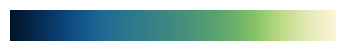

In [14]:
fig, ax = plt.subplots(figsize=figsize_colorbar)
gradient = np.vstack([np.linspace(0, 1, 256)] * 2)
ax.imshow(gradient, aspect='auto', cmap=cmap)
ax.axis('off')
fig.savefig(fig5_dir / 'd_colorbar.pdf')
plt.show()

### Panel e: balance disruption vs. overlap

In [15]:
figsize_OL_error = (3.2*cm, 2.5*cm)

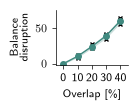

In [16]:
fig, ax = plt.subplots(figsize=figsize_OL_error)

mean = np.array([results[o]['init_abs_error'].mean() for o in overlaps])
std = np.array([results[o]['init_abs_error'].std() for o in overlaps])
ax.plot(labels, mean, 'o-', color=color_accent, linewidth=linewidth, markersize=4, zorder=2)
ax.fill_between(labels, mean - std, mean + std, color=color_accent, alpha=0.2, zorder=1)
for label, o in zip(labels, overlaps):
    vals = results[o]['init_abs_error']
    ax.plot([label] * len(vals), vals, 'x', color='black', markersize=3, zorder=1)

ax.set_ylabel('Balance\ndisruption')
ax.set_xlabel(r'Overlap [\%]')
ax.set_ylim(-1, 1.2 * np.max(mean + std))
ax.set_xlim(-0.5, len(labels) - 0.5)

fig.savefig(fig5_dir / 'e_balance_disruption.pdf', bbox_inches='tight')
plt.show()

### Panel f: training loss over time

In [17]:
figsize_learning_trajectory = (5*cm, 2.6*cm)
ylim_loss = (1e-3, 1e0)
xticks_time = [0, 180, 360, 540, 720]

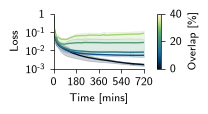

In [18]:
fig, ax = plt.subplots(1, 1, figsize=figsize_learning_trajectory)
max_overlap = overlaps[-1]

for label, o in zip(labels, overlaps):
    color = cmap(cmap_max_val * o / max_overlap)
    loss = results[o]['loss']
    mean_loss, std_loss = loss.mean(0), loss.std(0)
    ax.plot(X_TRAINING, mean_loss, label=label, color=color, linewidth=linewidth)
    ax.fill_between(X_TRAINING, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.2)

ax.set_yscale('log')
ax.set_ylim(*ylim_loss)
ax.set_yticks([1e-3, 1e-2, 1e-1, 1e0])
ax.set_yticklabels([r'10\textsuperscript{-3}', r'10\textsuperscript{-2}',
                    r'10\textsuperscript{-1}', r'1'])
ax.set_xlabel(X_LABEL_TRAINING)
ax.set_ylabel('Loss')
ax.set_xlim(0, X_TRAINING[-1])
if X_AXIS_TRAINING == 'time':
    ax.set_xticks(xticks_time)
    ax.set_xticklabels(xticks_time)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=cmap_max_val))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.05, aspect=15)
cbar.set_label(r'Overlap [\%]')
cbar.set_ticks([0, cmap_max_val * 0.5, cmap_max_val])
cbar.set_ticklabels(['0', rf'{int(max_overlap / 2)}', rf'{max_overlap}'])

fig.savefig(fig5_dir / 'f_loss_trajectories.pdf', bbox_inches='tight')
plt.show()

### Panels g, h: final performance vs. overlap

In [19]:
figsize_performance = (8.5*cm, 2.6*cm)
ylim_R2 = (0.5, 1.05)

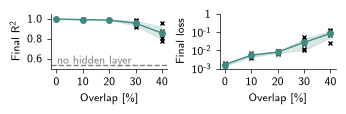

In [20]:
def plot_vs_overlap(ax, key):
    mean = np.array([results[o][key].mean() for o in overlaps])
    std = np.array([results[o][key].std() for o in overlaps])
    ax.plot(labels, mean, 'o-', color=color_accent, linewidth=linewidth, markersize=4, zorder=2)
    ax.fill_between(labels, mean - std, mean + std, color=color_accent, alpha=0.2, zorder=1)
    for label, o in zip(labels, overlaps):
        vals = results[o][key]
        ax.plot([label] * len(vals), vals, 'x', color='black', markersize=3, zorder=1)
    ax.set_xlabel(r'Overlap [\%]')


fig = MultiPanel(grid=[2], figsize=figsize_performance)

ax = fig.panels[0]
plot_vs_overlap(ax, 'final_R2')
ax.set_ylim(*ylim_R2)
ax.set_yticks([0.6, 0.8, 1.0])
ax.set_yticklabels([0.6, 0.8, 1.0])
ax.set_ylabel(r'Final $R^2$')

# no hidden layer baseline
ax.axhline(R2_NO_HIDDEN, color=color_openloop, linestyle='dashed', lw=linewidth)
ax.text(0.05, 0.05, r'no hidden layer', color=color_openloop, fontsize=8,
        ha='left', va='bottom', transform=ax.transAxes)

ax = fig.panels[1]
plot_vs_overlap(ax, 'final_loss')
ax.set_ylabel('Final loss')
ax.set_yscale('log')
ax.set_ylim(*ylim_loss)
ax.set_yticks([1e-3, 1e-2, 1e-1, 1e0])
ax.set_yticklabels([r'10\textsuperscript{-3}', r'10\textsuperscript{-2}',
                    r'10\textsuperscript{-1}', r'1'])

plt.savefig(fig5_dir / 'g-h_final_performance.pdf')
plt.show()